In [5]:
#了解ASII,unicode和utf-8编码
print('a')  #对应的ASCII码是97
print(ord('a'))  #ord函数可以查看字符对应的ASCII码
print(chr(97))  #chr函数可以查看ASCII码对应的字符
print('中')  #对应的Unicode编码是20013
print(ord('中'))  #ord函数可以查看字符对应的Unicode编码
print(chr(20013))  #chr函数可以查看Unicode编码对应的字符

#unicode只是解决了身份位置，但是没有解决怎么在内存里存储的问题
# 接下来就需要用到utf-8编码，前缀识别法
print('中'.encode('utf-8'))  #utf-8编码会把一个字符转换成多个字节存储
print(b'\xe4\xb8\xad'.decode('utf-8'))  #可以通过decode方法把字节转换成字符，这里是三个字节

a
97
a
中
20013
中
b'\xe4\xb8\xad'
中


In [1]:
# 以鲁为例子
print('鲁')
print(ord('鲁'))  #查看Unicode编码
print(bin(ord('鲁')))  #查看Unicode编码的二进制表示 0b1001110010000001这里为16bit 0bxxx
print(hex(ord('鲁')))  #查看Unicode编码的十六进制表示 0x9c81
print('鲁'.encode('utf-8'))  #查看utf-8编码 b'\xe9\xb2\x81'

鲁
40065
0b1001110010000001
0x9c81
b'\xe9\xb2\x81'


In [19]:
import regex

# 使用 [ ] 将空格包裹起来，防止被 VERBOSE 模式忽略
GPT2_PAT = regex.compile(r"""
    's|'t|'re|'ve|'m|'ll|'d       # 英语缩写
    | [ ]?\p{L}+                  # 字母序列（前面可能有空格 -> 用 [ ]? 表示）
    | [ ]?\p{N}+                  # 数字序列（前面可能有空格）
    | [ ]?[^\s\p{L}\p{N}]+        # 其他非字母数字字符序列（标点等）
    | \s+(?!\S)                   # 后面没有非空白字符的空白（通常是行尾空白）
    | \s+                         # 其他空白字符
""", regex.VERBOSE)


def gpt_pre_tokenize(text):
    tokens = GPT2_PAT.findall(text)
    return tokens


# 测试
text = "banana"
tokens = gpt_pre_tokenize(text)
for word in tokens:
    word_ids = list(word.encode("utf-8"))  #把每一个单词的字节编码组合为列表
    print(word_ids)
print(tokens)

[98, 97, 110, 97, 110, 97]
['banana']


In [16]:
import collections
import regex

class BPE_From_Scratch:
"""
步骤1，字节化和初始化，初始词表为0-255，每一个字节都是一个独立的token
步骤2，构建统计字典，统计预分词后的token对出现的频率
步骤3，寻找最高频率的字节对，合并为一个新的token，更新词表和文本
步骤4，重复步骤2和3，直到达到预设的词表大小或者没有更多的token对可以合并
性能优化：采用倒排索引来加速频率统计和更新文本
终止条件：达到预设的词表大小或者没有更多的token对可以合并
结果输出：最终的词表和编码后的文本
"""

def __init__(self, vocab_size=1000):
    """
    初始化BPE模型
    这里的vocab_size是指最终想要的词表大小
    由于初始词表已经有256个token（0-255的字节），
    因此实际需要通过合并生成的新token数量是vocab_size - 256
    这样可以确保最终的词表大小达到预期
    当然，如果vocab_size小于256，则表示不需要进行任何合并操作
    直接使用初始的字节词表即可
    :param self:
    :param vocab_size: 词表大小
    :return: 
    """
    self.vocab_size = vocab_size
    # 初始词表：0-255 的 ASCII值
    # 格式: {token_id: bytes}
    self.vocab = {i: bytes([i]) for i in range(256)}
    # 记录合并规则：(token_a, token_b) -> new_token_id
    self.merges = {}
    self.next_token_id = 256
    self.GPT2_PAT = regex.compile(r"""
                        's|'t|'re|'ve|'m|'ll|'d       # 英语缩写
                        | [ ]?\p{L}+                  # 字母序列（前面可能有空格 -> 用 [ ]? 表示）
                        | [ ]?\p{N}+                  # 数字序列（前面可能有空格）
                        | [ ]?[^\s\p{L}\p{N}]+        # 其他非字母数字字符序列（标点等）
                        | \s+(?!\S)                   # 后面没有非空白字符的空白（通常是行尾空白）
                        | \s+                         # 其他空白字符
                    """, regex.VERBOSE)
def gpt_pre_tokenize(self, text):
    tokens = GPT2_PAT.findall(text)
    return tokens

def build_dict(selfs, words):
    """
    构建统计字典，统计预分词后的token对出现的频率
    :param selfs:               
    :param words: 预分词的列表
    :return: 返回频率字典，格式为单词的字节表示:频率
    """
    word_frep = collections.defaultdict(int)  #创建一个空字典,记录每个单词出现的频率，该字典和普通的字典类似，但是当访问一个不存在的键时，会自动创建该键并赋值为默认值（这里是0）   
    for word in words:
        0 = tuple(word.encode("utf-8"))  #字典的键是单词的字节表示,元组，值是该单词出现的频率
        word_frep[word_bytes] += 1
    return word_frep  #返回频率字典，格式为单词的字节表示:频率

def update_word_freqs(self, pair, new_token_id, word_freqs):
    """
    helper function: 将字典中所有出现的 pair 替换为 new_token_id
    """
    new_word_freqs = collections.defaultdict(int)

    # 遍历旧字典
    for word_tuple, freq in word_freqs.items():
        # 优化：如果当前单词不包含 pair 的第一个字符，肯定不需要替换，直接保留
        if pair[0] not in word_tuple:
            new_word_freqs[word_tuple] += freq
            continue

        # 开始查找并替换
        new_tuple = []
        i = 0
        while i < len(word_tuple):
            # 检查是否匹配我们要合并的 pair
            if i < len(word_tuple) - 1 and word_tuple[i] == pair[0] and word_tuple[i + 1] == pair[1]:
                new_tuple.append(new_token_id)  # 写入新 ID
                i += 2  # 指针跳过两个旧字符
            else:
                new_tuple.append(word_tuple[i])  # 写入旧字符
                i += 1  # 指针正常前进

        # 将处理后的新元组存入新字典
        new_word_freqs[tuple(new_tuple)] += freq

    return new_word_freqs

def train(self, text):
    """
    步骤3，寻找最高频率的字节对，合并为一个新的token，更新词表和文本
    :param text: 训练集文本
    :return: self.vocab, self.merges
    """
    # 预分词 GPT2_PAT 正则使用
    words = gpt_pre_tokenize(text)
    # 构建频率字典
    word_frep = self.build_dict(words)
    # for _word, freq in word_frep.items():
    #     print(_word, freq)  #输出每个单词的字节表示及其频率
    while len(self.vocab) < self.vocab_size:  #只要词表没满，就一直训练
        #统计字节对出现的频率，每一个预分词后的词的相邻字节对，不会发生跨词的情况
        pairs = collections.defaultdict(int)
        for word_tuple, freq in word_frep.items():  #遍历频率字典 格式如(97, 97) 1，第一个是元组，第二个是频率
            for i in range(len(word_tuple) - 1):  #遍历单词的每一个字节
                pair = (word_tuple[i], word_tuple[i + 1])  # 取出相邻的字节对
                pairs[pair] += freq  #加权统计（加上单词出现的频率）,因为字典是唯一的，但是字典的value是出现的频率，所以要加上频率
        #寻找最高频率的字节对
        if not pairs:
            # print("[Stop] 没有更多的 token 对可以合并")
            break
        best_pair = max(pairs, key=pairs.get)  #寻找最大值对应的键
        best_count = pairs[best_pair]
        print(f"Merge: {best_pair} -> Count: {best_count}")
        #更新词表
        new_token_id = self.next_token_id
        self.vocab[new_token_id] = self.vocab[best_pair[0]] + self.vocab[best_pair[1]]
        self.merges[best_pair] = new_token_id
        self.next_token_id += 1  #更新id
        #打印更新后的词表
        # print(f"Updated Vocab Size: {len(self.vocab)}")
        # 更新文本数据 (最麻烦但必须做的一步)
        # -------------------------------------------------------
        # 你需要把 word_frep 里的 (108, 108) 全部替换成 (256)
        # 否则下一轮循环进来，pairs 统计到的还是 108, 108
        word_frep = self.update_word_freqs(best_pair, new_token_id, word_frep)
        # print(f"Updated Vocab Size: {len(self.vocab)}")
    return self.vocab, self.merges
def encode(self, text):
    # 1. 还是先预分词，不然会把单词连起来
    words = self.gpt_pre_tokenize(text)
    ids = []

    for word in words:
        # 把每个单词转成基础 ID 列表
        word_ids = list(word.encode("utf-8"))
        print(word_ids)
        while len(word_ids) >= 2:
            # --- 核心：寻找当前单词里所有能合并的 pair ---
            # 比如 word_ids = [h, e, l, l, o]
            # 这一步会找出所有在 self.merges 里出现过的相邻对
            stats = {}
            for i in range(len(word_ids) - 1):
                pair = (word_ids[i], word_ids[i + 1])
                if pair in self.merges:
                    # 记录这个 pair 对应的 新ID (作为优先级的依据)
                    stats[pair] = self.merges[pair]

            # 如果这就没找到任何能合并的，说明这个词处理完了
            if not stats:
                break

            # --- 决策：谁的 ID 最小（最早被 merge 的），就先合并谁 ---
            # min 函数会根据 value (新ID) 来找最小的 key (pair)
            pair_to_merge = min(stats, key=stats.get)
            new_id = self.merges[pair_to_merge]

            # --- 执行合并 (跟 train 里的逻辑一样) ---
            new_ids = []
            i = 0
            while i < len(word_ids):
                if i < len(word_ids) - 1 and word_ids[i] == pair_to_merge[0] and word_ids[i + 1] == pair_to_merge[1]:
                    new_ids.append(new_id)
                    i += 2
                else:
                    new_ids.append(word_ids[i])
                    i += 1
            word_ids = new_ids  # 更新当前单词的 ID 列表

        # 把处理完的单词加入最终结果
        ids.extend(word_ids)

    return ids

def decode(self, ids):
    # 1. 创建一个反向词表: id -> bytes
    # 注意：这里需要把 vocab 里的 bytes 拼起来
    # 但是为了简单，我们可以直接用现有的 vocab，因为 vocab 已经是 {id: bytes} 格式了
    # 只需要把列表里的 bytes 拼接起来即可

    # 修正：你的 vocab 里的 value 是 bytes，比如 b'a' 或者 b'ab'
    tokens = b"".join([self.vocab[idx] for idx in ids])

    # 转回字符串
    return tokens.decode("utf-8", errors="replace")


开始训练 BPE，目标词表大小: 300
训练完成，最终词表大小: 279
Encoded: [259, 264]
Decoded: Hello world
模型已保存到 my_tokenizer.json
模型已从 my_tokenizer.json 加载
Reloaded Decode: Hello world


In [15]:
# 你的测试代码
bpe = BPE_From_Scratch()
ids = bpe.encode(" ab aa")
# 注意原文里有空格！
# 预期过程：
# " ab" -> (32, 97, 98) -> (256, 98) -> (257) 
# " aa" -> (32, 97, 97) -> (256, 97) -> (258)
# 最终 ids 应该很短，比如 [257, 258]

print(f"编码ID: {ids}")
print(f"解码回原文: {bpe.decode(ids)}")

[32, 97, 98]
[32, 97, 97]
编码ID: [32, 97, 98, 32, 97, 97]
解码回原文:  ab aa


In [12]:
text_data = "aa ab aa ab ac aa ad aa ab"
bpe = BPE_From_Scratch()
bpe.train(text_data)
print(bpe.encode("abc bcac ccc"))

Merge: (32, 97) -> Count: 8
Merge: (256, 98) -> Count: 3
Merge: (256, 97) -> Count: 3
Merge: (97, 97) -> Count: 1
Merge: (256, 99) -> Count: 1
Merge: (256, 100) -> Count: 1
[97, 98, 99]
[32, 98, 99, 97, 99]
[32, 99, 99, 99]
[97, 98, 99, 32, 98, 99, 97, 99, 32, 99, 99, 99]


In [42]:
text_data = "aa ab aa ab ac aa ad aa ab"
bpe = BPE_From_Scratch()
# bpe.train(text_data)
word_frep = bpe.build_dict(gpt_pre_tokenize(text_data))
print(word_frep)  #输出每个单词的字节表示及其频
pairs = collections.defaultdict(int)
for word_tuple, freq in word_frep.items():  #遍历频率字典 格式如(97, 97) 1，第一个是元组，第二个是频率
    for i in range(len(word_tuple) - 1):  #遍历单词的每一个字节
        pair = (word_tuple[i], word_tuple[i + 1])  # 取出相邻的字节对
        pairs[pair] += freq  #加权统计（加上单词出现的频率）,因为字典是唯一的，但是字典的value是出现的频率，所以要加上频率
for _pair, count in pairs.items():
    print(f"Pair: {_pair} -> Count: {count}")

defaultdict(<class 'int'>, {(97, 97): 1, (32, 97, 98): 3, (32, 97, 97): 3, (32, 97, 99): 1, (32, 97, 100): 1})
Pair: (97, 97) -> Count: 4
Pair: (32, 97) -> Count: 8
Pair: (97, 98) -> Count: 3
Pair: (97, 99) -> Count: 1
Pair: (97, 100) -> Count: 1


In [34]:
vocab = {i: bytes([i]) for i in range(256)}
print(vocab[97])  #b'a'
# text_data = "aa ab aa ab ac aa ad aa ab"
# words = gpt_pre_tokenize(text_data)
# print(words)
# bpe = BPE_From_Scratch()
# word_freqs = bpe.build_dict(words)
# print(word_freqs)  #输出每个单词的字节表示及其频率

b'a'


In [ ]:
import collections


class BPE_From_Scratch:
    """
    步骤1，字节化和初始化，初始词表为0-255，每一个字节都是一个独立的token
    步骤2，构建统计字典，统计预分词后的token对出现的频率
    步骤3，寻找最高频率的字节对，合并为一个新的token，更新词表和文本
    步骤4，重复步骤2和3，直到达到预设的词表大小或者没有更多的token对可以合并
    性能优化：采用倒排索引来加速频率统计和更新文本
    终止条件：达到预设的词表大小或者没有更多的token对可以合并
    结果输出：最终的词表和编码后的文本
    """

    def __init__(self, vocab_size=1000):
        self.vocab_size = vocab_size
        # 初始词表：0-255 的 ASCII/Byte 值
        # 格式: {token_id: bytes}
        self.vocab = {i: bytes([i]) for i in range(256)}
        # 记录合并规则：(token_a, token_b) -> new_token_id
        self.merges = {}
        self.next_token_id = 256

    def train(self, text):
        # -------------------------------------------------------------
        # 步骤1，字节化和初始化
        # -------------------------------------------------------------
        # 预分词 GPT2_PAT 正则使用
        words = gpt_pre_tokenize(text)

        # 将文本转换为 token 列表的频率字典
        # 例如: "hello" -> (104, 101, 108, 108, 111)
        word_freqs = collections.defaultdict(int)
        for word in words:
            # 将单词转为 UTF-8 字节流，再转为整数元组
            word_bytes = tuple(word.encode("utf-8"))
            word_freqs[word_bytes] += 1

        print(f"[Info] 初始词表大小: {len(self.vocab)}")
        print(f"[Info] 唯一单词数量: {len(word_freqs)}")

        # -------------------------------------------------------------
        # 步骤4，重复步骤2和3
        # -------------------------------------------------------------
        while len(self.vocab) < self.vocab_size:
            # -------------------------------------------------------------
            # 步骤2，构建统计字典
            # -------------------------------------------------------------
            pairs = collections.defaultdict(int)
            for word_tuple, freq in word_freqs.items():
                # 遍历当前单词中的所有相邻对
                for i in range(len(word_tuple) - 1):
                    pair = (word_tuple[i], word_tuple[i + 1])
                    pairs[pair] += freq  # 加权统计（乘以单词出现的频率）

            # -------------------------------------------------------------
            # 终止条件检查
            # -------------------------------------------------------------
            if not pairs:
                print("[Stop] 没有更多的 token 对可以合并")
                break

            # -------------------------------------------------------------
            # 步骤3，寻找最高频率的字节对，合并
            # -------------------------------------------------------------
            best_pair = max(pairs, key=pairs.get)
            best_count = pairs[best_pair]

            # 更新词表
            new_token_id = self.next_token_id
            self.vocab[new_token_id] = self.vocab[best_pair[0]] + self.vocab[best_pair[1]]
            self.merges[best_pair] = new_token_id
            self.next_token_id += 1

            # 更新文本（这里的“文本”是 word_freqs 字典）
            # 性能优化：只更新包含 best_pair 的单词，而不是全量扫描
            new_word_freqs = collections.defaultdict(int)
            for word_tuple, freq in word_freqs.items():
                # 如果这个单词里不包含我们要合并的对，直接保留
                if best_pair[0] not in word_tuple:
                    # 简单的过滤优化，实际可以使用更复杂的倒排索引
                    new_word_freqs[word_tuple] = freq
                    continue

                # 执行合并操作
                new_tuple = []
                i = 0
                while i < len(word_tuple):
                    # 检查是否匹配 best_pair
                    if i < len(word_tuple) - 1 and word_tuple[i] == best_pair[0] and word_tuple[i + 1] == best_pair[1]:
                        new_tuple.append(new_token_id)
                        i += 2  # 跳过两个
                    else:
                        new_tuple.append(word_tuple[i])
                        i += 1
                new_word_freqs[tuple(new_tuple)] = freq

            word_freqs = new_word_freqs

            # 打印日志
            if len(self.vocab) % 5 == 0:  # 每合并5次打印一次
                print(f"Merge: {best_pair} -> {new_token_id} (Count: {best_count})")

        # -------------------------------------------------------------
        # 结果输出
        # -------------------------------------------------------------
        print(f"\n[Done] 训练完成。最终词表大小: {len(self.vocab)}")
        return self.vocab, self.merges

    def encode(self, text):
        """
        使用训练好的 merges 规则对新文本进行编码
        """
        words = text.split()
        encoded_ids = []

        for word in words:
            # 初始状态：转为字节 ID
            word_ids = list(word.encode("utf-8"))

            while len(word_ids) >= 2:
                # 寻找当前单词中，所有可能的 pair，找到在 merges 中优先级最高（最早加入）的那个
                # 注意：实际 BPE 实现中，应该按照 merges 的加入顺序来合并
                stats = {}
                for i in range(len(word_ids) - 1):
                    pair = (word_ids[i], word_ids[i + 1])
                    if pair in self.merges:
                        # 我们需要知道这个 pair 是第几个被 merge 的，这里简化逻辑
                        stats[pair] = pair  # 简单占位，实际应存 priority

                if not stats:
                    break

                # 这里为了简单演示，假设只要在 merges 里就合并（实际应选最早 merge 的）
                # 找到当前单词中能合并的一对（这里简单取第一个匹配的）
                pair_to_merge = list(stats.keys())[0]
                new_id = self.merges[pair_to_merge]

                # 执行替换
                new_ids = []
                i = 0
                while i < len(word_ids):
                    if i < len(word_ids) - 1 and word_ids[i] == pair_to_merge[0] and word_ids[i + 1] == pair_to_merge[
                        1]:
                        new_ids.append(new_id)
                        i += 2
                    else:
                        new_ids.append(word_ids[i])
                        i += 1
                word_ids = new_ids

            encoded_ids.extend(word_ids)

        return encoded_ids


# -------------------------------------------------------------
# 测试代码
# -------------------------------------------------------------
if __name__ == "__main__":
    # 模拟一段重复度高的数据，方便观察合并效果
    # "aa" -> 97, 97 -> 合并
    text_data = "aa ab aa ab ac aa ad aa ab"

    # 实例化 BPE
    bpe = BPE_From_Scratch(vocab_size=260)  # 初始256，我们只想多训练4个词

    # 训练
    vocab, merges = bpe.train(text_data)

    # 打印部分结果
    print("\n--- Merges (合并规则) ---")
    for pair, new_id in merges.items():
        print(f"Pair {pair} -> New ID {new_id}")

    # 测试编码
    test_str = "ab aa ac"
    encoded = bpe.encode(test_str)
    print(f"\n--- Encode Test ---")
    print(f"原文: {test_str}")
    print(f"编码 ID: {encoded}")

In [20]:
# 训练数据下载
import requests
import os


def download_shakespeare():
    # 这是 Andrej Karpathy 提供的原始 txt 文件链接
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    file_path = "input.txt"

    if not os.path.exists(file_path):
        print(f"正在下载 {file_path}...")
        try:
            r = requests.get(url)
            with open(file_path, 'w', encoding='utf-8') as f:
                f.write(r.text)
            print(f"下载成功！文件大小: {len(r.text) / 1024 / 1024:.2f} MB")
        except Exception as e:
            print(f"下载失败: {e}")
            print("请检查网络，或者尝试方法 2 手动下载")
    else:
        print(f"{file_path} 已经存在，跳过下载。")


if __name__ == "__main__":
    download_shakespeare()

正在下载 input.txt...
下载成功！文件大小: 1.06 MB


In [21]:
# 手写Embedding

import torch
import torch.nn as nn


class ManualEmbedding(nn.Module):
    """
    纯手写 Embedding 层
    本质：维护一个可学习的大矩阵，并支持通过索引取出对应的行。
    """

    def __init__(self, vocab, d_model):
        # 必须调用父类初始化，否则 PyTorch 无法识别这是一个神经网络模块
        super().__init__()

        # -----------------------------------------------------------------
        # 步骤 1: 创建“货架” (Create Weight Matrix)
        # -----------------------------------------------------------------
        # torch.randn(...): 
        #   在内存中开辟一块空间，生成形状为 [词表大小, 向量维度] 的随机数。
        #   此时它还只是普通的“数据”。
        #
        # nn.Parameter(...): 
        #   这是点睛之笔！它给普通数据穿上了一层“马甲”。
        #   作用：告诉 PyTorch 引擎，“这个张量是模型的可训练参数”。
        #   后果：1. 它会自动出现在 model.parameters() 里。
        #         2. 反向传播时，优化器会计算它的梯度并更新它。
        self.weight = nn.Parameter(torch.randn(vocab, d_model))

        # -----------------------------------------------------------------
        # 步骤 2: 装修“货架” (Initialization)
        # -----------------------------------------------------------------
        # nn.init.normal_(...):
        #   我们不能直接用 randn 生成的原始随机数，因为它们方差可能太大（默认是1）。
        #   这里强制把数值重置为：均值 0，标准差 0.02。
        #   原因：这是 GPT-2/BERT 等模型的标准做法，数值小一点，模型学得稳一点。
        #   注意：函数名末尾的下划线 _ 表示 "In-place" 操作，直接修改 self.weight 本身。
        nn.init.normal_(self.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        # -----------------------------------------------------------------
        # 步骤 3: 机械臂取货 (Lookup / Advanced Indexing)
        # -----------------------------------------------------------------
        # 输入 idx: 
        #   形状通常是 [Batch_Size, Seq_Len]，里面的元素是整数 ID (如 5, 102, 0)。
        #
        # 操作 self.weight[idx]:
        #   这是 PyTorch/NumPy 的“高级索引”功能。
        #   它不是矩阵乘法，它是“物理搬运”。
        #   逻辑：如果 idx 里是 5，就去 self.weight 的第 5 行把整行数据拷贝出来。
        #
        # 输出形状:
        #   [Batch_Size, Seq_Len, embedding_dim]
        #   原来的每个 ID 变成了一个向量，维度增加了一级。
        return self.weight[idx]

In [23]:
def verify_equivalence():
    vocab_size = 1000
    n_embd = 64
    batch_size = 2
    seq_len = 5

    # --- 选手 A: 官方库 ---
    auto_emb = nn.Embedding(vocab_size, n_embd)

    # --- 选手 B: 手写版 ---
    manual_emb = ManualEmbedding(vocab_size, n_embd)

    # 【关键步骤】强制复制权重，确保起跑线一致
    # clone() 是为了让内存独立，互不影响
    manual_emb.weight.data = auto_emb.weight.data.clone()

    # 准备假数据
    input_ids = torch.randint(0, vocab_size, (batch_size, seq_len))

    # --- 第一回合：比前向传播 (输出值) ---
    out_auto = auto_emb(input_ids)
    out_manual = manual_emb(input_ids)

    # torch.allclose 用来比较两个浮点数张量是否“足够接近”
    forward_match = torch.allclose(out_auto, out_manual)
    print(f"前向传播结果一致? {forward_match}")

    # --- 第二回合：比反向传播 (梯度值) ---
    # 模拟一个 Loss，比如求和
    loss_auto = out_auto.sum()
    loss_manual = out_manual.sum()

    # 反向传播
    loss_auto.backward()
    loss_manual.backward()

    # 比较计算出来的梯度
    grad_match = torch.allclose(auto_emb.weight.grad, manual_emb.weight.grad)
    print(f"反向传播梯度一致? {grad_match}")

    # 打印前几个数值看看
    print("\n--- 抽样检查梯度值 (前3个) ---")
    print("官方库 Grad:", auto_emb.weight.grad.view(-1)[:3].tolist())
    print("手写版 Grad:", manual_emb.weight.grad.view(-1)[:3].tolist())


verify_equivalence()

前向传播结果一致? True
反向传播梯度一致? True

--- 抽样检查梯度值 (前3个) ---
官方库 Grad: [0.0, 0.0, 0.0]
手写版 Grad: [0.0, 0.0, 0.0]


In [29]:
import torch

vocab = 1000
d_model = 64
i = torch.arange(0, d_model, 2)
i.unsqueeze(0).shape

torch.Size([1, 32])

In [31]:
pos = torch.arange(0, vocab).unsqueeze(1)
pos.shape

torch.Size([1000, 1])

In [ ]:
import torch
import numpy as np
# 假设你的类都保存在 ManualEmbedding.py 和 BPE_Tokenizer.py 中
from BPE_Tokenizer import BPE_Tokenizer
from ManualEmbedding import ManualEmbedding, PositionEncoding

# --- 全局配置 ---
D_MODEL = 64  # 向量维度
MAX_LEN = 1000  # 最大长度
VOCAB_SIZE = 1000  # 词表大小


def test_pipeline():
    print("🚀 开始全流程测试...")

    # 1. 初始化所有组件
    tokenizer = BPE_Tokenizer(vocab_size=VOCAB_SIZE)
    # 这一步如果是真实场景，应该先 load 训练好的 tokenizer
    # tokenizer.load("...") 

    emb_layer = ManualEmbedding(num_embeddings=VOCAB_SIZE, embedding_dim=D_MODEL)
    pos_layer = PositionEncoding(d_model=D_MODEL, max_len=MAX_LEN)

    # 2. 造数据
    text = "Hello world"
    print(f"\n[Step 1] 原始文本: \"{text}\"")

    # 3. Tokenizer (Str -> List)
    token_ids = tokenizer.encode(text)
    print(f"[Step 2] Token IDs: {token_ids}")

    # 4. 转换 Tensor (List -> Tensor[B, T])
    # 模拟 Batch_Size = 1
    input_tensor = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0)
    print(f"[Step 3] Input Tensor Shape: {input_tensor.shape}")

    # 5. Embedding (Tensor[B, T] -> Tensor[B, T, C])
    x_emb = emb_layer(input_tensor)
    print(f"[Step 4] Embedding Output Shape: {x_emb.shape}")

    # 记录一下加位置编码前的值（为了对比）
    val_before = x_emb[0, 0, :5].detach().clone()

    # 6. Position Encoding (Add PE)
    x_final = pos_layer(x_emb)
    print(f"[Step 5] Final Output Shape: {x_final.shape}")

    # --- 关键验证 ---
    val_after = x_final[0, 0, :5].detach()

    print("\n🔍 数值验证 (前5位):")
    print(f"  Embedding 原值: {val_before.numpy()}")
    print(f"  加上位置编码后: {val_after.numpy()}")

    # 检查数值是否真的变了
    if not torch.equal(val_before, val_after):
        print("\n✅ 测试通过！位置编码已成功叠加到词向量上。")
        print("   数据形状变换: [B, T] -> [B, T, D] -> [B, T, D] (形状不变，数值改变)")
    else:
        print("\n❌ 测试失败！数值没有变化，请检查 PositionEncoding 的 forward 函数是否写了 return x + self.pe")


if __name__ == '__main__':
    test_pipeline()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SwiGLU(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        # 加上 bias=False，这是目前主流大模型的标配,因为后面有归一化，bais相当于没有了
        self.w_gate_value = nn.Linear(d_model, d_ff * 2, bias=False)
        self.w_out = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]

        # 1. 投影并切分
        # 输出维度是 d_ff * 2，所以这里直接解包(unpack)成两份
        gate, value = self.w_gate_value(x).chunk(2, dim=-1)

        # 2. SwiGLU 核心计算
        # Gate 过激活函数，Value 保持线性，然后相乘
        hidden = F.silu(gate) * value

        # 3. 输出投影
        return self.w_out(hidden)


# 测试一下
x = torch.randn(2, 10, 512)
model = SwiGLU(d_model=512, d_ff=1024)
print(model(x).shape)  # torch.Size([2, 10, 512]) -> 完美

torch.Size([2, 10, 512])


In [14]:
import torch
import torch.nn as nn


class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, head_dim, max_seq_len=2048, base=10000.0):
        """
        Args:
            head_dim: 每个头的维度 (例如 128)。注意：不要传 d_model！
            max_seq_len: 预计算的最大长度 (例如 4096)
            base: 频率基数 (默认 10000.0)
        """
        super().__init__()
        self.head_dim = head_dim
        self.max_seq_len = max_seq_len
        self.base = base

        # --- 1. 预计算频率 (Init阶段只做一次) ---
        # 对应公式：theta = 10000^(-2i/d)
        # 使用 log 空间计算更稳定: exp(-2i/d * ln(10000))
        inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))

        # --- 2. 预计算位置角度 (Cache) ---
        # 生成位置索引: [0, 1, ..., max_len-1]
        t = torch.arange(max_seq_len, dtype=inv_freq.dtype)

        # 外积计算: m * theta
        # 结果 shape: [max_seq_len, head_dim//2]
        freqs = torch.outer(t, inv_freq)

        # 转成复数形式 (模长=1, 角度=freqs)
        # 对应公式: e^(i * m * theta)
        freqs_cis = torch.polar(torch.ones_like(freqs), freqs)

        # 注册为 buffer：
        # 1. 不会作为参数更新 (无梯度)
        # 2. 会随模型保存 (state_dict)
        # 3. 会随模型上 GPU (.to(device))
        self.register_buffer('freqs_cis', freqs_cis, persistent=False)

    def forward(self, x):
        """
        输入 x: [batch, seq_len, num_heads, head_dim]
        输出: 旋转后的 x，形状不变
        """
        batch, seq_len, n_head, _ = x.shape

        # --- 3. 动态处理长度 ---
        # 如果推理长度超过了预计算长度，重新计算 (外推)
        if seq_len > self.max_seq_len:
            self.freqs_cis = self._update_freqs(seq_len, x.device)
            self.max_seq_len = seq_len

        # 取出当前长度对应的旋转角度
        # shape: [seq_len, head_dim//2]
        freqs_cis = self.freqs_cis[:seq_len]

        # --- 4. 调整形状以支持广播 ---
        # 我们需要让 freqs_cis 能跟 x 广播相乘
        # x 形状: [B, L, H, D]
        # freqs 需要变成: [1, L, 1, D/2]
        freqs_cis = freqs_cis.view(1, seq_len, 1, self.head_dim // 2)

        # --- 5. 应用旋转 (核心计算) ---
        # 把 x 变成复数 -> 乘法旋转 -> 变回实数
        x_rotated = self.apply_rotary_emb(x, freqs_cis)

        return x_rotated

    def _update_freqs(self, seq_len, device):
        # 辅助函数：用于超长推理时的临时重新计算
        inv_freq = 1.0 / (self.base ** (torch.arange(0, self.head_dim, 2).float() / self.head_dim)).to(device)
        t = torch.arange(seq_len, device=device, dtype=inv_freq.dtype)
        freqs = torch.outer(t, inv_freq)
        return torch.polar(torch.ones_like(freqs), freqs)

    def apply_rotary_emb(self, x, freqs_cis):
        """
        x: [B, L, H, D] (实数)
        freqs_cis: [1, L, 1, D/2] (复数)
        """
        # 1. 把输入 x 的最后一维两两结合，变成复数
        # reshape: [B, L, H, D] -> [B, L, H, D/2, 2]
        # view_as_complex: -> [B, L, H, D/2]
        x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))

        # 2. 复数乘法 (这就是旋转！)
        x_out_complex = x_complex * freqs_cis

        # 3. 变回实数并展平
        # view_as_real: -> [B, L, H, D/2, 2]
        # flatten: -> [B, L, H, D]
        x_out = torch.view_as_real(x_out_complex).flatten(3)

        return x_out.type_as(x)  # 保持输入的数据类型(fp16/fp32)


# 模拟参数
batch_size = 2
seq_len = 10
n_heads = 8
d_model = 512
head_dim = d_model // n_heads  # 64

# 1. 实例化 RoPE
rope = RotaryPositionalEmbedding(head_dim=head_dim)

# 2. 模拟 Attention 里的 Query (Q)
# 形状必须是 [batch, seq, heads, head_dim]
q = torch.randn(batch_size, seq_len, n_heads, head_dim)

# 3. 前向传播
q_rotated = rope(q)

print(f"输入形状: {q.shape}")
print(f"输出形状: {q_rotated.shape}")

# 验证最后两维是否守恒 (简单的数学验证)
# 旋转不改变向量模长，只改变方向
norm_input = torch.norm(q, dim=-1)
norm_output = torch.norm(q_rotated, dim=-1)

# 允许一点点浮点误差
if torch.allclose(norm_input, norm_output, atol=1e-4):
    print("✅ 测试成功：尺寸正确且旋转后模长不变！")
else:
    print("❌ 测试失败：模长发生了改变。")

输入形状: torch.Size([2, 10, 8, 64])
输出形状: torch.Size([2, 10, 8, 64])
✅ 测试成功：尺寸正确且旋转后模长不变！


In [13]:
import torch

torch.arange(0, 1000).unsqueeze(1).shape

torch.Size([1000, 1])

In [42]:
import torch
import torch.nn as nn
import torch.functional as F
import math


class Rotate(nn.Module):
    def __init__(self, head_model, max_len):
        super().__init__()
        self.head_model = head_model
        self.max_len = max_len
        #划分子空间
        subspace = torch.arange(0, head_model, 2)  #0-d_k/2-1
        #计算theta
        theta = torch.exp(-subspace * math.log(10000.0) / self.head_model).float()
        #计算具体角度和位置有关
        pos = torch.arange(0, self.max_len).unsqueeze(1).float()

        angle = pos * theta  #shape [max_len,head_model/2]
        #因为后面要进行拼接，所以这里要进行重复
        angle = torch.repeat_interleave(angle, 2, dim=-1)  #shape [max_len,head_model]
        # 正确点：求 angle 的余弦
        # register_buffer: 保证数据随模型去 GPU，且不被当做参数更新
        self.register_buffer('cos_cached', angle.cos().view(1, 1, max_len, head_model))
        self.register_buffer('sin_cached', angle.sin().view(1, 1, max_len, head_model))

    def _reverse_test(self, x):  #这个只是用最简单的来演示一下
        #输入尺寸为[batch,head,seq_len,head_model]
        #先进行转置 将seq_len 和head_model交换达到转置的效果 ---> [batch,head,head_model,seq_len]
        x_t = x.transpose(-1, -2)
        # 创建一个容器来存放变换后的结果
        x_out_t = torch.zeros_like(x_t)
        #将最后两维进行变换和加负号，最后两维形状[head_model,seq_len] 进行0行和1行交换，且0行加负号，2行和3行交换且2行加负号，以此类推
        for i in range(0, self.head_model, 2):
            x_out_t[:, :, i, :] = x_t[:, :, i + 1, :] * -1
            x_out_t[:, :, i + 1, :] = x_t[:, :, i, :]
        return x_out_t.transpose(-1, -2)  #再转置回来

    def _reverse(self, x):
        #输入尺寸为[batch,head,seq_len,head_model]
        #把最后一维变成（组数 ，2）
        x = x.view(x.shape[:-1] + (-1, 2))  #变成[batch heads seq_len head_model/2 2]
        #x.shape[:-1]只在最后一个维度进行变化
        #拆解,因为最后一维是2，所以拆成两个张亮
        x1, x2 = x.unbind(dim=-1)
        #旋转
        x_out = torch.stack((-x2, x1), dim=-1)
        #再变回原来的形状
        return x_out.flatten(-2)

    def forward(self, x):
        # 获取当前输入的序列长度
        seq_len = x.shape[2]

        # 必须进行切片
        # 因为 x 可能比 max_len 短，所以只取前面 seq_len 长度的 cos/sin
        current_cos = self.cos_cached[:, :, :seq_len, :]
        current_sin = self.sin_cached[:, :, :seq_len, :]

        # 执行公式: x * cos + reverse(x) * sin
        return x * current_cos + self._reverse(x) * current_sin


# --- 验证代码 (你可以直接运行看结果) ---
if __name__ == '__main__':
    # 模拟一个小输入
    batch, heads, seq_len, dim = 2, 2, 5, 8
    rope = Rotate(head_model=dim, max_len=20)

    x = torch.randn(batch, heads, seq_len, dim)

    # 运行 Forward
    y = rope(x)

    print(f"输入形状: {x.shape}")
    print(f"输出形状: {y.shape}")

    # 验证一致性
    res1 = rope._reverse(x)
    res2 = rope._reverse_test(x)
    diff = (res1 - res2).abs().sum()
    print(f"两种 Reverse 方法的差异值: {diff.item()} (应该是 0.0)")

输入形状: torch.Size([2, 2, 5, 8])
输出形状: torch.Size([2, 2, 5, 8])
两种 Reverse 方法的差异值: 0.0 (应该是 0.0)


In [16]:
import torch

x = torch.arange(16).reshape(4, 4).float()
print(x)
x_t = x.transpose(-1, -2)  #转置
print("转置后")
print(x_t)
#切换
x_out_t = torch.zeros_like(x_t)
for i in range(0, 4, 2):
    #按照行变换的
    x_out_t[i] = x_t[i + 1] * -1
    x_out_t[i + 1] = x_t[i]
print('变换后')
print(x_out_t)


tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]])
转置后
tensor([[ 0.,  4.,  8., 12.],
        [ 1.,  5.,  9., 13.],
        [ 2.,  6., 10., 14.],
        [ 3.,  7., 11., 15.]])
变换后
tensor([[ -1.,  -5.,  -9., -13.],
        [  0.,   4.,   8.,  12.],
        [ -3.,  -7., -11., -15.],
        [  2.,   6.,  10.,  14.]])


In [40]:
#用矩阵的view方法来改进
import torch

x = torch.arange(16).reshape(4, 4).float()
# print(x)
x_bak = x
# print(x.shape)#[4, 4]
x = x.view(x.shape[:-1] + (-1, 2))
# x.shape#[4, 2, 2]
# print(x)
x1, x2 = x.unbind(-1)
x = torch.stack((-x2, x1), -1)
# print(x)
# 再展平
# print(x.flatten(-2))
x_rever = x.flatten(-2)

#测试自己的思路
print(x_bak.shape)  #[4, 4]
# x_rever.shape#[4, 4]

# x=x_bak.flatten(-2)
# x_bak =x_bak.flatten()
# print(x_bak)
# print(x_rever)


torch.Size([4, 4])


torch.Size([4, 4])

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, rotatelayer: Rotate, dropout=0.01, max_len=1000):
        """
        :param d_model: 特征维度 (例如 512)
        :param n_heads: 头数 (例如 8)
        :param rotatelayer: 外部传入的旋转位置编码实例
        :param dropout: dropout 概率
        """      
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.dropout = nn.Dropout(dropout)
        
        # 确保能整除
        assert d_model % n_heads == 0, "d_model 必须能被 n_heads 整除"
        self.head_model = self.d_model // self.n_heads # 每个头的维数
        
        # --- QKV 权重构造 ---
        # 注意：先定义 Linear，输入输出都是 d_model
        self.w_q = nn.Linear(d_model, d_model, bias=False)#因为后面要归一化，所以偏置值没有用
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        
        # --- 输出投影层 ---
        # 合并头之后需要这一层来混合信息
        self.w_o = nn.Linear(d_model, d_model, bias=False)
        
        # --- 注入 RoPE ---
        self.rotate = rotatelayer
        
        # --- ★★★ 掩码实现 (Register Buffer) ★★★ ---
        # 创建一个下三角矩阵 (tril)，对角线及左下角为 1，右上角为 0
        # shape: [1, 1, max_len, max_len] 以便广播到 [batch, heads, ...]
        """
        # torch.ones: 造一个全 1 的方阵
        # torch.tril: (Triangle Lower) 只保留左下角，把右上角全变成 0
        self.register_buffer("bias", torch.tril(torch.ones(max_len, max_len))
                                     .view(1, 1, max_len, max_len))
        """
        self.register_buffer("bias", torch.tril(torch.ones(max_len, max_len))
                                     .view(1, 1, max_len, max_len))#注册到gpu

    def forward(self, x):
        """
        :param x: [batch, seq_len, d_model]
        :return: [batch, seq_len, d_model]
        """
        # 获取尺寸
        batch, seq_len, _ = x.shape
        
        # --- 步骤 1: 线性投影 (Linear Projection) ---
        # 先把 d_model 维度的特征算出来
        # shape [batch, seq_len, d_model]
        q = self.w_q(x)
        k = self.w_k(x)
        v = self.w_v(x)
        
        # --- 步骤 2: 拆分多头 (Split Heads) ---
        # view: [batch, seq_len, n_heads, head_model]
        # transpose: [batch, n_heads, seq_len, head_model] (把头放到前面，方便并行)
        q = q.view(batch, seq_len, self.n_heads, self.head_model).transpose(1, 2)
        k = k.view(batch, seq_len, self.n_heads, self.head_model).transpose(1, 2)
        v = v.view(batch, seq_len, self.n_heads, self.head_model).transpose(1, 2)
        
        # --- 步骤 3: 旋转位置编码 (RoPE) ---
        # 只对 Q 和 K 进行旋转，V 不动
        q = self.rotate(q)
        k = self.rotate(k)
        
        # --- 步骤 4: 计算注意力分数 (Attention Scores) ---
        # Q @ K^T
        # q: [b, h, seq, d]
        # k.transpose: [b, h, d, seq]#后面那俩维度进行转置
        # result: [b, h, seq, seq]
        # 注意：这里要除以 sqrt(head_model)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_model)
        
        # --- 步骤 5: ★★★ 应用掩码 (Mask) ★★★ ---
        # 截取当前 seq_len 大小的 mask
        #因为注意力分数是[b, h, seq, seq]
        mask = self.bias[:, :, :seq_len, :seq_len]#切出符合当前矩阵的尺寸，随着一句话的长度变化而变化
        # 将 mask 为 0 的位置 (未来信息) 填为负无穷 (-inf)
        scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # --- 步骤 6: 归一化与加权 (Softmax & Value) ---
        # 在最后一维 (seq_len) 上做 softmax
        attn_weights = F.softmax(scores, dim=-1)#因为每一列都是我的不同对象，我要我看我和哪一个对象更紧凑，所以是-1那一维度
        attn_weights = self.dropout(attn_weights)
        
        # 加权求和: weights @ V
        # [b, h, seq, seq] @ [b, h, seq, d] -> [b, h, seq, d]
        out = torch.matmul(attn_weights, v)
        
        # --- 步骤 7: 合并头 (Merge Heads) ---
        # transpose: [b, seq, h, d]
        # flatten/view: [b, seq, d_model]
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model)#.contiguous()它申请了一块新内存，按照你现在的逻辑顺序，把书真正地搬了一次家。
        #.view() 必须要求内存连续。
        
        # 最后的输出线性层
        return self.w_o(out)


        
    
        

In [44]:
# ==========================================
# 3. 验证代码 (直接运行看结果)
# ==========================================
if __name__ == '__main__':
    # 模拟参数
    batch_size = 2
    max_len = 10
    d_model = 64   # 总维度
    n_heads = 4    # 头数
    head_model = d_model // n_heads # 16
    seq_len = 5    # 当前输入长度
    
    # 1. 实例化 RoPE
    rope = Rotate(head_model=head_model, max_len=max_len)
    
    # 2. 实例化 Attention
    attn = CausalSelfAttention(
        d_model=d_model, 
        n_heads=n_heads, 
        rotatelayer=rope, 
        max_len=max_len
    )
    
    # 3. 构造输入数据
    x = torch.randn(batch_size, seq_len, d_model)
    
    # 4. 前向传播
    y = attn(x)
    
    print("-" * 30)
    print(f"输入尺寸: {x.shape}") # [2, 5, 64]
    print(f"输出尺寸: {y.shape}") # [2, 5, 64]
    print("代码运行成功，维度匹配正确！")
    print("-" * 30)        
        

------------------------------
输入尺寸: torch.Size([2, 5, 64])
输出尺寸: torch.Size([2, 5, 64])
代码运行成功，维度匹配正确！
------------------------------


In [1]:
# Cell 1: 准备工作
import torch
import time
import config as conf
from LLM import LLM
from BPE_Tokenizer import BPE_Tokenizer

# 1. 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用设备: {device}")

# 2. 加载配置和 Tokenizer

# 假设你的 Tokenizer 需要重新初始化或者加载
tokenizer = BPE_Tokenizer(vocab_size=conf.vocab_size) 
tokenizer.load("shakespeare_tokenizer.json")

# 3. 初始化模型
print("正在加载模型...")
model = LLM(conf).to(device)

# 4. 加载权重
try:
    model.load_state_dict(torch.load("mini_llama.pth", map_location=device,weights_only=True))
    print("✅ 权重加载成功！")
except FileNotFoundError:
    print("❌ 没找到 mini_llama.pth，请检查路径！")

# 5. 开启评估模式
model.eval()


正在使用设备: cuda
模型加载完毕，包含特殊 Token: ['<|endoftext|>', '<|padding|>']
正在加载模型...
✅ 权重加载成功！


LLM(
  (embedding): ManualEmbedding()
  (rotate): Rotate()
  (transformer_blocks): ModuleList(
    (0-7): 8 x TransformerBlock(
      (rmsnorm): RMSNorm()
      (catt_mask_rotate): CausalSelfAttention(
        (dropout): Dropout(p=0.01, inplace=False)
        (w_q): Linear(in_features=256, out_features=256, bias=False)
        (w_k): Linear(in_features=256, out_features=256, bias=False)
        (w_v): Linear(in_features=256, out_features=256, bias=False)
        (w_o): Linear(in_features=256, out_features=256, bias=False)
        (rotate): Rotate()
      )
      (ffn): SwiGLU(
        (w_gate_value): Linear(in_features=256, out_features=2048, bias=False)
        (w_out): Linear(in_features=1024, out_features=256, bias=False)
      )
    )
  )
  (final_norm): RMSNorm()
  (output_linear): Linear(in_features=256, out_features=512, bias=False)
)

In [2]:
# Cell 2: 定义生成功能的函数
def chat_with_shakespeare(start_text, max_new=200):
    if not start_text.strip():
        print("开头不能为空！")
        return

    # 1. 编码
    try:
        input_ids = tokenizer.encode(start_text)
        input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    except Exception as e:
        print(f"编码出错: {e}")
        return

    # 2. 生成 (计时)
    print(f"🤖 正在思考: '{start_text}' 后面接什么...")
    start_time = time.time()
    
    with torch.no_grad():
        generated_ids = model.generate(input_tensor, max_new_tokens=max_new)
        
    end_time = time.time()
    
    # 3. 解码
    output_text = tokenizer.decode(generated_ids[0].tolist())
    
    # 4. 打印结果
    speed = (len(generated_ids[0]) - len(input_ids)) / (end_time - start_time)
    print("\n" + "="*40)
    print(output_text)
    print("="*40)
    print(f"⚡ 速度: {speed:.2f} tokens/sec")

In [3]:
# Cell 3: 在这里改开头，反复运行！

# 比如试试这些开头：
# "To be or not to be"
# "The king said"
# "O Romeo"
# "Thou art"

prompt = "The king said"  # <--- 改这里

chat_with_shakespeare(prompt, max_new=100)

🤖 正在思考: 'The king said' 后面接什么...

The king saidd come home that have more than dhideom have comes in.

First Servingman:
But when she cames, how no
⚡ 速度: 63.42 tokens/sec


In [5]:
import torch
import math

class AdamWOptimizer:
    def __init__(self, params, betas=(0.9, 0.999), lr=1e-3, weight_decay=1e-2, eps=1e-8):
        """
        :param params: 需要更新的参数列表 (通常由 model.parameters() 传入)
        :param betas: (beta1, beta2) 元组
        :param lr: 学习率
        :param weight_decay: 权重衰减系数
        :param eps: 防止除零的平滑项
        """
        self.params = list(params) # 将生成器转为列表
        self.beta1, self.beta2 = betas
        self.lr = lr
        self.weight_decay = weight_decay
        self.eps = eps
        
        # 状态存储：使用参数的 id() 作为 key，确保能对应到唯一的参数
        self.m = {} #一阶矩
        self.s = {} #二阶矩
        self.t = 0 #时间步

    def step(self):
        """
        执行一步参数更新
        不需要传入 grads，直接读取 param.grad
        """
        self.t += 1
        
        # 禁用梯度计算，因为优化器更新步骤不需要构建计算图，节省显存
        with torch.no_grad():
            for p in self.params:
                # 如果该参数没有梯度（例如被冻结），则跳过
                if p.grad is None:
                    continue
                
                # 获取梯度
                grad = p.grad
                
                # 初始化状态
                p_id = id(p)#获取参数的唯一标识符
                if p_id not in self.m:
                    self.m[p_id] = torch.zeros_like(p)
                    self.s[p_id] = torch.zeros_like(p)
                
                # 1. 更新动量 (In-place)
                # m = beta1 * m + (1 - beta1) * g
                self.m[p_id].mul_(self.beta1).add_(grad, alpha=1 - self.beta1)
                
                # 2. 更新二阶动量 (In-place)
                # s = beta2 * s + (1 - beta2) * g^2
                self.s[p_id].mul_(self.beta2).addcmul_(grad, grad, value=1 - self.beta2)
                
                # 3. 计算偏差修正 (Bias Correction)
                bias_correction1 = 1 - self.beta1 ** self.t
                bias_correction2 = 1 - self.beta2 ** self.t
                
                # 计算自适应学习率部分
                # denorm = sqrt(s) / sqrt(correction2) + eps
                step_size = self.lr / bias_correction1
                denom = (self.s[p_id].sqrt() / math.sqrt(bias_correction2)).add_(self.eps)
                
                # 4. AdamW 的核心：先进行权重衰减 (Weight Decay)
                # w = w - lr * lambda * w
                if self.weight_decay != 0:
                    p.mul_(1 - self.lr * self.weight_decay)
                
                # 5. 参数更新 (Gradient Descent Step)
                # w = w - step_size * (m / denom)
                # addcdiv_ 实现: p = p - step_size * (m / denom)
                p.addcdiv_(self.m[p_id], denom, value=-step_size)

In [6]:
# === 验证代码 ===
# 模拟数据
X = torch.randn(100, 1)
y_true = 3 * X + 2 + 0.1 * torch.randn(100, 1) # y = 3x + 2 + noise

# 简单的线性模型 y = wx + b
w = torch.tensor([0.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# 使用我们重写的 AdamW
optimizer = AdamWOptimizer([w, b], lr=0.1, weight_decay=0.01)

print(f"训练前: w={w.item():.4f}, b={b.item():.4f}")

for epoch in range(100):
    # 1. 前向传播
    y_pred = w * X + b
    
    # 2. 计算 Loss (MSE)
    loss = ((y_pred - y_true)**2).mean()
    
    # 3. 清空梯度 (手动清空，如果是 PyTorch 内置优化器通常是 optimizer.zero_grad())
    if w.grad is not None: w.grad.zero_()
    if b.grad is not None: b.grad.zero_()
    
    # 4. 反向传播
    loss.backward()
    
    # 5. 更新参数
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss={loss.item():.4f}, w={w.item():.4f}, b={b.item():.4f}")

print("-" * 30)
print(f"训练后: w={w.item():.4f}, b={b.item():.4f}")
print("目标值: w=3.0000, b=2.0000")

训练前: w=0.0000, b=0.0000
Epoch 0: Loss=14.6804, w=0.1000, b=0.1000
Epoch 20: Loss=1.4702, w=1.9362, b=1.8407
Epoch 40: Loss=0.0910, w=2.9549, b=2.2739
Epoch 60: Loss=0.0167, w=3.0748, b=1.9493
Epoch 80: Loss=0.0116, w=2.9723, b=1.9549
------------------------------
训练后: w=2.9535, b=2.0069
目标值: w=3.0000, b=2.0000


In [ ]:
"""
学习率 (LR)
  ^
  |          max_lr
  |           /  \
  |          /    \   <-- 余弦衰减 (Cosine Decay)
  |         /      \
  |        /        \
  |       /          \__ min_lr ___________
  |      /           |                 |
  |     /            |                 |
  |____/_____________|_________________|____> 时间 (Steps)
      ^              ^                 ^
  warmup_steps   (decay区间)       hold_steps
"""

"""
余弦退热阶段做的事
# 1. 把时间轴平移，让起点变成 0
局部步数 = 当前步数 - 预热步数

# 2. 算出局部区间的总长度，也就是余弦阶段要的总步数
局部总长 = 总步数 - 预热步数 - 保持步数

# 3. 算出 0.0 到 1.0 的进度
进度 = 局部步数 / 局部总长

# 4. 代入余弦 (0 -> pi)
# 这样当进度为0时，cos(0)=1 (最高点)
# 当进度为1时，cos(pi)=-1 (最低点)
系数 = 0.5 * (1 + cos(进度 * pi))
"""

In [7]:
#手动实现余弦退热算法
import math
"""
升温 -> 余弦退热 -> 保持”
"""
def warm_cos_keep(current_step,total_step,max_lr,min_lr,warmup_steps,hold_steps):
    """
    :param current_step: 当前步数
    :param total_step: 总步数
    :param max_lr: 最大学习率
    :param min_lr: 最小学习率
    :param warmup_steps: 预热步数
    :param hold_steps: 保持步数
    :return: 
    """
    #升温
    if current_step < warmup_steps:
        #线性增长
        lr = max_lr * (current_step / warmup_steps)
    #余弦退热
    elif current_step < total_step - hold_steps:
        lr = min_lr + 0.5*(max_lr - min_lr) * (1 + math.cos(current_step/(total_step-warmup_steps-hold_steps)*math.pi))
    #保持
    else :
        lr = min_lr
    return lr
        

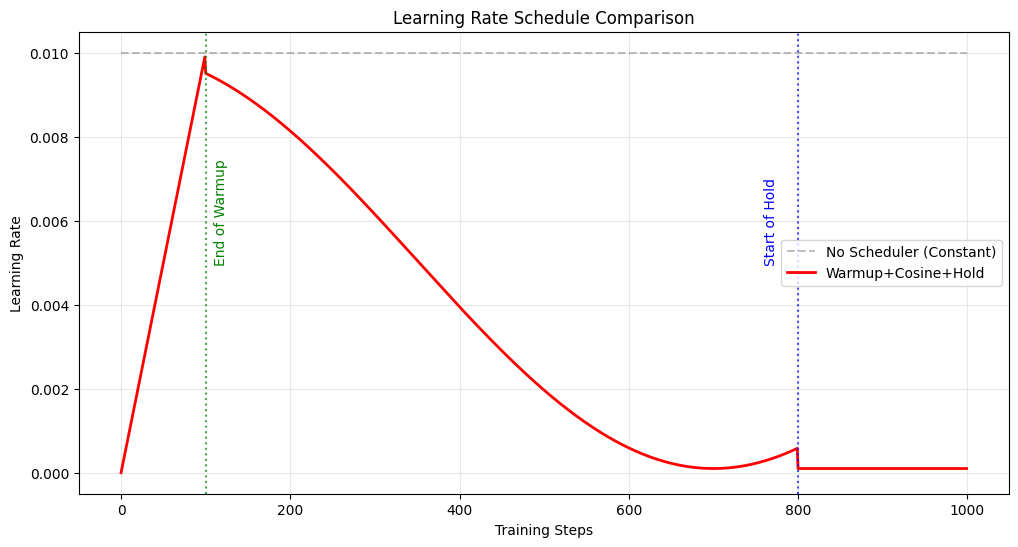

In [8]:
import matplotlib.pyplot as plt
# 1. 设置模拟参数
TOTAL_STEPS = 1000   # 模拟跑 1000 步
MAX_LR = 0.01        # 最高 0.01
MIN_LR = 0.0001      # 最低 0.0001
WARMUP = 100         # 前 100 步升温 (10%)
HOLD = 200           # 最后 200 步保持 (20%)

# 2. 生成数据
lr_with_scheduler = []    # 你的算法
lr_no_scheduler = []      # 对比组：普通恒定学习率

for step in range(TOTAL_STEPS):
    # A. 使用你的调度器
    lr_1 = warm_cos_keep(step, TOTAL_STEPS, MAX_LR, MIN_LR, WARMUP, HOLD)
    lr_with_scheduler.append(lr_1)
    
    # B. 不使用调度器 (一直是最高)
    lr_no_scheduler.append(MAX_LR)

# 3. 开始画图
plt.figure(figsize=(12, 6))

# 画第一条线：无调度器 (虚线)
plt.plot(lr_no_scheduler, label='No Scheduler (Constant)', color='gray', linestyle='--', alpha=0.5)

# 画第二条线：你的算法 (实线，红色)
plt.plot(lr_with_scheduler, label='Warmup+Cosine+Hold', color='red', linewidth=2)

# --- 为了好看，标出三个阶段的分界线 ---
# 标出 Warmup 结束点
plt.axvline(x=WARMUP, color='green', linestyle=':', alpha=0.7)
plt.text(WARMUP + 10, MAX_LR * 0.5, 'End of Warmup', color='green', rotation=90)

# 标出 Hold 开始点
plt.axvline(x=TOTAL_STEPS - HOLD, color='blue', linestyle=':', alpha=0.7)
plt.text(TOTAL_STEPS - HOLD - 40, MAX_LR * 0.5, 'Start of Hold', color='blue', rotation=90)

# 设置图表信息
plt.title('Learning Rate Schedule Comparison')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.legend()

# 显示图片
plt.show()

In [3]:
import math

def warm_cos_keep(current_step, total_step, max_lr, min_lr, warmup_steps, hold_steps):
    # 升温
    if current_step < warmup_steps:
        lr = max_lr * (current_step / warmup_steps)
    
    # 余弦退热
    elif current_step < total_step - hold_steps:
        # ★★★ 修正这里 ★★★
        # 我们定义 decay_step，表示"衰减阶段已经跑了多少步"
        # 当 current_step == warmup_steps 时，decay_step 为 0，cos(0)=1，完美衔接 max_lr
        decay_step = current_step - warmup_steps 
        
        decay_total = total_step - warmup_steps - hold_steps
        
        lr = min_lr + 0.5 * (max_lr - min_lr) * (
                    1 + math.cos(decay_step / decay_total * math.pi))
    
    # 保持
    else:
        lr = min_lr
    return lr

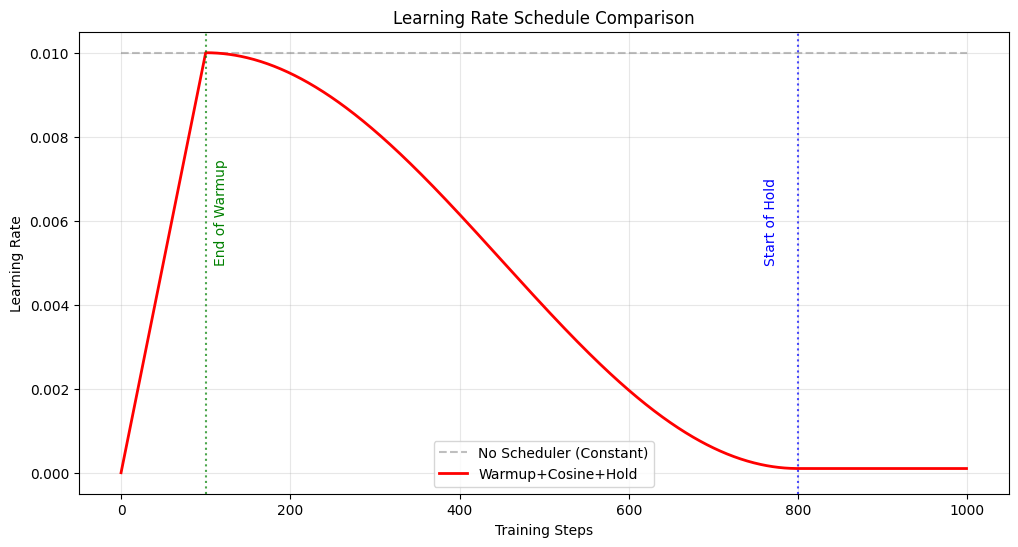

In [5]:
import matplotlib.pyplot as plt
# 1. 设置模拟参数
TOTAL_STEPS = 1000   # 模拟跑 1000 步
MAX_LR = 0.01        # 最高 0.01
MIN_LR = 0.0001      # 最低 0.0001
WARMUP = 100         # 前 100 步升温 (10%)
HOLD = 200           # 最后 200 步保持 (20%)

# 2. 生成数据
lr_with_scheduler = []    # 你的算法
lr_no_scheduler = []      # 对比组：普通恒定学习率

for step in range(TOTAL_STEPS):
    # A. 使用你的调度器
    lr_1 = warm_cos_keep(step, TOTAL_STEPS, MAX_LR, MIN_LR, WARMUP, HOLD)
    lr_with_scheduler.append(lr_1)
    
    # B. 不使用调度器 (一直是最高)
    lr_no_scheduler.append(MAX_LR)

# 3. 开始画图
plt.figure(figsize=(12, 6))

# 画第一条线：无调度器 (虚线)
plt.plot(lr_no_scheduler, label='No Scheduler (Constant)', color='gray', linestyle='--', alpha=0.5)

# 画第二条线：你的算法 (实线，红色)
plt.plot(lr_with_scheduler, label='Warmup+Cosine+Hold', color='red', linewidth=2)

# --- 为了好看，标出三个阶段的分界线 ---
# 标出 Warmup 结束点
plt.axvline(x=WARMUP, color='green', linestyle=':', alpha=0.7)
plt.text(WARMUP + 10, MAX_LR * 0.5, 'End of Warmup', color='green', rotation=90)

# 标出 Hold 开始点
plt.axvline(x=TOTAL_STEPS - HOLD, color='blue', linestyle=':', alpha=0.7)
plt.text(TOTAL_STEPS - HOLD - 40, MAX_LR * 0.5, 'Start of Hold', color='blue', rotation=90)

# 设置图表信息
plt.title('Learning Rate Schedule Comparison')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.legend()

# 显示图片
plt.show()

In [13]:
import random

import wandb
# ==========================================
# 2. 主逻辑：模拟并上传 WandB
# ==========================================

# A. 初始化 WandB
# project: 项目名称 (在网页上显示的文件夹名)
# name: 这次实验的名称
wandb.init(project="LR-Schedule-Demo", name="visualize_custom_scheduler")

# B. 设置模拟参数
TOTAL_STEPS = 1000   
MAX_LR = 0.01        
MIN_LR = 0.0001      
WARMUP = 100         # 前 10%
HOLD = 200           # 后 20%

print("🚀 开始模拟并上传数据到 WandB...")

# C. 模拟循环
for step in range(TOTAL_STEPS):
    # 1. 计算你的算法值
    lr_custom = wram_cos_keep(step, TOTAL_STEPS, MAX_LR, MIN_LR, WARMUP, HOLD)
    
    # 2. 对比组 (恒定)
    lr_constant = MAX_LR
    
    # 3. ★★★ 核心步骤：记录到 WandB ★★★
    # 这里的 key (比如 "lr/custom") 就是网页上图表的标题
    wandb.log({
        "step": step,                    # X轴
        "lr/my_scheduler": lr_custom,    # Y轴1: 你的红线
        "lr/constant": lr_constant,      # Y轴2: 对比的灰线
        "phase_marker/max_lr": MAX_LR,   # 辅助线: 标出最高点
        "phase_marker/min_lr": MIN_LR    # 辅助线: 标出最低点
    })

# D. 结束上传
wandb.finish()

print("✅ 完成！请点击上面的链接在 WandB 网页查看曲线。")

🚀 开始模拟并上传数据到 WandB...


lr/constant,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/my_scheduler,▂▂██████▇▇▇▆▅▅▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
phase_marker/max_lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
phase_marker/min_lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█
lr/constant,0.01
lr/my_scheduler,0.0001
phase_marker/max_lr,0.01
phase_marker/min_lr,0.0001
step,999


✅ 完成！请点击上面的链接在 WandB 网页查看曲线。


In [11]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="machine_learn",
    # Set the wandb project where this run will be logged.
    project="test_ai",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


acc,▁▄▆▇▅▆█▇
loss,█▇▂▃▂▁▁▁
acc,0.77953
loss,0.2242


In [15]:
# 📄 文件名: download_wiki.py
import json
from datasets import load_dataset
from tqdm import tqdm

def prepare_wiki():
    print("⏳ 正在从 HuggingFace 下载维基百科精简版 (约500MB)...")
    # 自动下载并加载数据
    # 如果下载慢，可以开启镜像: export HF_ENDPOINT=https://hf-mirror.com
    dataset = load_dataset("pleisto/wikipedia-cn-20230720-filtered", split="train")
    
    output_file = "wiki.txt"
    print(f"✅ 下载完成! 正在转换为纯文本: {output_file} ...")
    
    with open(output_file, "w", encoding="utf-8") as f:
        # data['completion'] 里存的是正文
        for item in tqdm(dataset):
            text = item['completion']
            # 过滤掉太短的条目
            if len(text) > 100:
                f.write(text + "\n<|end|>\n") # 加上结束符
                
    print(f"🎉 搞定! 现在你可以直接运行 python train_pretrain.py 了")


prepare_wiki()

⏳ 正在从 HuggingFace 下载维基百科精简版 (约500MB)...


README.md: 0.00B [00:00, ?B/s]

C:\Users\lushiji\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lushiji\.cache\huggingface\hub\datasets--pleisto--wikipedia-cn-20230720-filtered. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed.

wikipedia-cn-20230720-filtered.json:   0%|          | 0.00/524M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

✅ 下载完成! 正在转换为纯文本: wiki.txt ...


100%|██████████| 254547/254547 [00:08<00:00, 30623.77it/s]


🎉 搞定! 现在你可以直接运行 python train_pretrain.py 了


In [16]:
import re
import os
from tqdm import tqdm

class DataCleaner:
    def __init__(self):
        # 1. 定义什么算“标题” (特征：字数少，且不是以句号/叹号/问号结尾)
        # 这里的 20 是经验值，你可以根据实际数据调整
        self.header_pattern = re.compile(r'^.{1,20}$') 
        self.punctuation = ('.', '。', '!', '！', '?', '？', '"', '”', '…')

    def is_likely_header(self, line):
        """判断一行是否像是一个‘标题’"""
        line = line.strip()
        # 如果太长，肯定不是标题，是正文
        if len(line) > 25: 
            return False
        # 如果以标点符号结尾，说明是句子，不是标题
        if line.endswith(self.punctuation):
            return False
        # 如果是纯数字或极短，可能是列表项，算作正文保留
        if line.isdigit():
            return False
        return True

    def clean_text_block(self, raw_lines):
        """
        核心清洗逻辑：处理单个条目（从 <|end|> 到下一个 <|end|> 之间的内容）
        """
        cleaned_lines = []
        
        # 第一步：基础清洗（去空格、全角转半角）
        temp_lines = []
        for line in raw_lines:
            # 替换全角空格和不可见字符
            line = line.replace('\u3000', ' ').replace('\xa0', ' ').strip()
            if not line:
                continue # 扔掉空行
            if line == "<|end|>": # 暂时不处理结束符
                continue
            temp_lines.append(line)

        # 第二步：高级清洗（去空标题）
        # 我们使用 while 循环来灵活控制索引，方便向后看一行 (Lookahead)
        i = 0
        while i < len(temp_lines):
            current_line = temp_lines[i]
            
            # 判断当前行是不是标题
            if self.is_likely_header(current_line):
                # 看看下一行是否存在
                if i + 1 < len(temp_lines):
                    next_line = temp_lines[i+1]
                    # ★★★ 核心逻辑 ★★★
                    # 如果当前是标题，且下一行也是标题 -> 说明当前标题是空的 -> 删掉！
                    if self.is_likely_header(next_line):
                        i += 1
                        continue # 跳过当前行（即删除了空标题）
                else:
                    # 如果当前是标题，但已经是最后一行了 -> 说明是悬空标题 -> 删掉！
                    i += 1
                    continue

            cleaned_lines.append(current_line)
            i += 1

        # 如果清洗完只剩很少的内容（比如只剩一个标题），这数据也没用，直接丢弃
        if len(cleaned_lines) < 2:
            return None
            
        return "\n".join(cleaned_lines) + "\n<|end|>\n"

def process_file(input_path, output_path):
    cleaner = DataCleaner()
    
    if not os.path.exists(input_path):
        print(f"❌ 找不到输入文件: {input_path}")
        return

    print(f"🧹 开始清洗: {input_path} -> {output_path}")
    
    with open(input_path, 'r', encoding='utf-8') as f_in, \
         open(output_path, 'w', encoding='utf-8') as f_out:
        
        buffer = []
        # 使用 tqdm 显示进度 (按字节估算)
        pbar = tqdm(total=os.path.getsize(input_path), unit='B', unit_scale=True)
        
        for line in f_in:
            pbar.update(len(line.encode('utf-8')))
            
            # 遇到结束符，说明凑齐了一个条目，开始清洗
            if "<|end|>" in line:
                if buffer:
                    cleaned_block = cleaner.clean_text_block(buffer)
                    if cleaned_block:
                        f_out.write(cleaned_block)
                buffer = [] # 清空缓冲区
            else:
                buffer.append(line)
        
        # 处理文件末尾可能残留的最后一段
        if buffer:
            cleaned_block = cleaner.clean_text_block(buffer)
            if cleaned_block:
                f_out.write(cleaned_block)
                
    print("\n✅ 数据清洗完成！")


# 配置你的文件路径
INPUT_FILE = "wiki.txt"          # 你的原始脏数据
OUTPUT_FILE = "wiki_clean.txt"   # 清洗后的干净数据

process_file(INPUT_FILE, OUTPUT_FILE)

🧹 开始清洗: wiki.txt -> wiki_clean.txt


 99%|█████████▊| 504M/511M [00:08<00:00, 63.2MB/s] 


✅ 数据清洗完成！


 99%|█████████▉| 507M/511M [00:08<00:00, 60.6MB/s]


In [1]:
import torch

def gradient_clipping(parameters, max_norm, norm_type=2):
    """
    手动实现梯度裁剪 (In-place 操作)
    :param parameters: 模型参数迭代器 (model.parameters())
    :param max_norm: 最大范数阈值
    :param norm_type: 范数类型 (默认 L2)
    """
    # 1. 【关键修正】将生成器转为列表，防止迭代器耗尽
    # 同时过滤掉没有梯度的参数
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    params = [p for p in parameters if p.grad is not None]#指向同一个显存地址的指针。
    
    # 如果没有参数需要裁剪，直接返回
    if len(params) == 0:
        return
    
    max_norm = float(max_norm)
    norm_type = float(norm_type)

    # 2. 计算总范数 (Total Norm)
    # 公式: sqrt( sum( |g|^2 ) )
    total_norm = torch.tensor(0.0)
    
    for p in params:
        # p.grad.detach() 防止计算图不断累积，省显存
        param_norm = p.grad.detach().data.norm(norm_type)
        total_norm += param_norm ** norm_type
        
    total_norm = total_norm ** (1. / norm_type)

    # 3. 计算裁剪系数
    # 加上 1e-6 防止分母为 0
    clip_coef = max_norm / (total_norm + 1e-6)
    
    # 4. 进行裁剪
    # 只有当 total_norm > max_norm (即 clip_coef < 1) 时才需要缩放
    if clip_coef < 1:
        for p in params:
            # .mul_ 是原地乘法 (In-place)
            p.grad.detach().data.mul_(clip_coef)
            
    # 通常返回 total_norm 方便监控
    return total_norm



In [2]:
# 模拟一个简单的参数
w = torch.tensor([3.0, 4.0], requires_grad=True)
loss = 10 * (w ** 2).sum()
loss.backward()

print(f"裁剪前梯度: {w.grad}") # 应该是 [60.0, 80.0], 范数是 100.0

# 设定最大范数为 1.0 (强制裁剪)
gradient_clipping(w, max_norm=1.0)

print(f"裁剪后梯度: {w.grad}") # 应该是 [0.6, 0.8], 范数是 1.0

裁剪前梯度: tensor([60., 80.])
裁剪后梯度: tensor([0.6000, 0.8000])


In [1]:
#测试模型
import torch
from LLM import LLM  # 你的模型文件
from BPE_Tokenizer import BPE_Tokenizer # 你的分词器
import os
from IPython.display import display, Markdown # 用于漂亮的显示
import config as conf
# ================= 🔧 必须配置的部分 =================

MODEL_PATH = "sft_llama.pth" # 你的权重文件名
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"🖥️ 运行设备: {DEVICE}")
def load_model():
    print("⏳ 正在初始化分词器...")
    try:
        tokenizer = BPE_Tokenizer()
        tokenizer.load("chinese_tokenizer.json")
    except Exception as e:
        print(f"❌ 分词器加载失败: {e}")
        return None, None

    print(f"⏳ 正在加载模型权重: {MODEL_PATH} ...")
    
    # 初始化模型
    model = LLM(conf).to(DEVICE)

    # 加载权重
    if os.path.exists(MODEL_PATH):
        try:
            state_dict = torch.load(MODEL_PATH, map_location=DEVICE,weights_only=True)
            model.load_state_dict(state_dict, strict=False) # strict=False 可以容忍微小的key差异
            print("✅ 模型加载成功！准备就绪。")
        except Exception as e:
            print(f"❌ 权重加载报错: {e}")
            print("💡 提示：请检查 MODEL_CONFIG 里的层数、维度是否与训练时一致。")
    else:
        print("❌ 找不到 .pth 文件，请检查路径。")
    
    model.eval() # 切换到评估模式 (关闭 Dropout)
    return model, tokenizer

# 执行加载
model, tokenizer = load_model()

🖥️ 运行设备: cuda
⏳ 正在初始化分词器...
模型加载完毕，包含特殊 Token: ['<|endoftext|>', '<|padding|>', '<|user|>', '<|assistant|>', '<|end|>']
⏳ 正在加载模型权重: sft_llama.pth ...
✅ 模型加载成功！准备就绪。


In [5]:
def count_parameters(model):
    # 计算所有 requires_grad=True 的参数
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 模型总参数量: {total_params:,}")
    print(f"💾 估算模型权重大小: {total_params * 4 / (1024*1024):.2f} MB (FP32)")

count_parameters(model)

📊 模型总参数量: 56,897,024
💾 估算模型权重大小: 217.04 MB (FP32)


In [15]:
def generate_response(model, tokenizer, question, max_new_tokens=100, temperature=0.7, top_k=50, repetition_penalty=1.2):
    """
    终极版生成函数：支持温度、Top-K 采样、复读惩罚
    """
    if model is None: return "模型未加载"
    
    prompt = f"<|user|>\n{question}\n<|assistant|>\n"
    input_ids = tokenizer.encode(prompt)
    x = torch.tensor([input_ids], dtype=torch.long).to(DEVICE)
    end_token_id = tokenizer.special_tokens.get("<|end|>", 0)
    
    generated_ids = [] # 记录生成的 token 用于查重
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(x)
            next_token_logits = logits[:, -1, :]
            
            # -------------------------------------------
            # 🔧 核心改进 1: 复读惩罚 (Repetition Penalty)
            # -------------------------------------------
            # 如果某个词之前出现过，就降低它的分数
            for token_id in set(generated_ids):
                # 如果 logit 是正数，除以 penalty；如果是负数，乘以 penalty
                if next_token_logits[0, token_id] < 0:
                    next_token_logits[0, token_id] *= repetition_penalty
                else:
                    next_token_logits[0, token_id] /= repetition_penalty

            # -------------------------------------------
            # 🔧 核心改进 2: Top-K 采样 (截断长尾低概率词)
            # -------------------------------------------
            # 只保留概率最高的 K 个词，剩下的全部屏蔽 (-inf)
            if top_k > 0:
                v, _ = torch.topk(next_token_logits, top_k)
                min_v = v[:, -1]
                next_token_logits[next_token_logits < min_v.unsqueeze(1)] = -float('Inf')

            # 温度采样
            if temperature > 0:
                probs = torch.softmax(next_token_logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                next_token = torch.argmax(next_token_logits, dim=-1).unsqueeze(0)
            
            token_item = next_token.item()
            if token_item == end_token_id: break
            
            # 记录生成的 token
            generated_ids.append(token_item)
            x = torch.cat([x, next_token], dim=1)
            
    # 一次性解码，避免一个个字蹦出来有乱码
    return tokenizer.decode(generated_ids)

def chat_display(question, temperature=0.7, max_new_tokens=100, top_k=50, repetition_penalty=1.0):
    """
    修正版：外层函数现在支持所有高级参数了
    """
    # 显示用户问题
    display(Markdown(f"**👤 User:** {question}"))
    
    # 生成回答 (把参数全部透传给 generate_response)
    response = generate_response(
        model, 
        tokenizer, 
        question, 
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        repetition_penalty=repetition_penalty  
    )
    
    # 显示模型回答
    display(Markdown(f"> **🤖 Assistant:** {response}"))
    print("-" * 40)

In [18]:
# 降低温度，让模型不要瞎猜，尽量选概率最大的词
print("--- 温度 0.1 测试 ---")
chat_display("你好，你是谁？", temperature=0.1)

print("--- 温度 0.1 测试 ---")
chat_display("1+1等于几？", temperature=0.1)
# 稍微给一点点温度 (0.3)，配合复读惩罚 (1.2)
chat_display("你好，你是谁？", temperature=0.3, repetition_penalty=1.2)

--- 温度 0.1 测试 ---


**👤 User:** 你好，你是谁？

> **🤖 Assistant:** 我是我最喜欢的人。我有机会探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界，探索世界世界遗产之路。

----------------------------------------
--- 温度 0.1 测试 ---


**👤 User:** 1+1等于几？

> **🤖 Assistant:** 1+1=几何，因为1+1=几何中，1+1=几何中。

----------------------------------------


**👤 User:** 你好，你是谁？

> **🤖 Assistant:** 我是我的一个好主意。

----------------------------------------


In [17]:
# 测试问题列表
test_questions = [
    "你好，你是谁？",
    "请把'Good morning'翻译成中文。",
    "1+1等于几？",
    "写一首关于春天的古诗。",
    "如何学习深度学习？"
]

for q in test_questions:
    chat_display(q)

**👤 User:** 你好，你是谁？

> **🤖 Assistant:** 我是我最好的朋友，总是爱你。我相信我在这里度过了一段困难或有氧的旅途。我也要享受在我的朋友和家人朋友之间前进和打击我们的想法。我还会一起做一些有趣或有氧运动。我也可以有点小心于自己，并经常做一些事情。最后，我也会是我最有帮助的，我很乐意带你，在心中保持积极态度，并有时会带来美好的

----------------------------------------


**👤 User:** 请把'Good morning'翻译成中文。

> **🤖 Assistant:** Good morning是一位美国作家，他写了小说《小林》。

...

> **🤖 Assistant:** 在春天的日子，
阳光的微风吹过树林，
春天降临。
春天降临，
春天降临在它的位置。
春天的春天，
秋天的宁静在空气中奔跑。

----------------------------------------


**👤 User:** 如何学习深度学习？

> **🤖 Assistant:** 神经网络是一种人工智能型量子模型，它可以在许多不同的应用中部署。神经网络可以用于各种应用，如计算机系统识别、自然语言处理和智能自动化。

----------------------------------------


In [18]:
while True:
    q = input("请输入问题 (输入 q 退出): ")
    if q.lower() == 'q':
        break
    chat_display(q)

**👤 User:** 你好

> **🤖 Assistant:** 你好，当我阅读我的阅世记时，我对我的工作充满热情，我可以读取您的技能，获得一些知识，并经常进行体育锻炼。我还喜欢在我生命中的边界找工作，在她的父母工作时应该一起工作，但我总是愿意交谈，并变得很从小就被分配。

----------------------------------------


**👤 User:** 

> **🤖 Assistant:** - 北越
- 南越
- 南越
- 北越

...

> **🤖 Assistant:** 我最近会去位于西方，越来越多的人类活动是非常不同文化的。我的会计学研究包括研究、书面、信仰、��教、研究、教育和文化等，这些领域有更多的人类活动。

----------------------------------------


**👤 User:** 

> **🤖 Assistant:** 最近为什么会带来很多挑战：
- 世界在历史上扮演着重要角色
- 世界在今天的世界中扮演着重要的角色
- 世界在今天的世界中扮演着重要的角色
- 世界在过去的考虑和机遇
- 世界在未来创造了哪些挑战
- 世界在日常生活中扮演着重要的角色
- 世界在生活的许多方面都非常友好
- 世界在未来带来了许多挑战
- 世界在日常生活中拥有强大的潜力

----------------------------------------
